In [2]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ast import literal_eval
import sys
import os
# import plotly.express as px
# import plotly.graph_objects as go
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path
from src.utils import visualization_utils

In [4]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/coronaviridae/20240313/uniref/coronaviridae_s_uniref90_embl_hosts_pruned_metadata_corrected_species_virus_host.csv")
df = pd.read_csv(file_path)
df

,uniref90_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank
0,UniRef90_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
1,UniRef90_A0A0K0KPB6,31631,[9606],AIL49495.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
2,UniRef90_A0A0K0KPM4,31631,[9606],AIL49520.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
3,UniRef90_A0A0K0KPR8,31631,[9606],AIL49509.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
4,UniRef90_A0A0K0L8I8,31631,[9606],AIV41891.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
...,...,...,...,...,...,...,...,...,...,...
809,UniRef90_A0A8F0ZUE2,1906673,NaN,QWN56394.1,['Hipposideros larvatus'],hipposideros larvatus,Alphacoronavirus sp.,species,175524,species
810,UniRef90_A0A8F0ZUI9,1906673,NaN,QWN56350.1,['Rhinolophus malayanus'],rhinolophus malayanus,Alphacoronavirus sp.,species,608659,species
811,UniRef90_A0A8F0ZVS0,1906673,NaN,QWN56358.1,['Murina cyclotis'],murina cyclotis,Alphacoronavirus sp.,species,177185,species
812,UniRef90_A0A8F0ZWQ8,1906673,NaN,QWN56401.1,['Myotis laniger'],myotis laniger,Alphacoronavirus sp.,species,452654,species


In [5]:
n = df.shape[0]
n

814

In [6]:
def get_label(pct, threshold):
    if pct <= threshold:
        return ""
    else:
        return f"{pct:.2f}%"

In [7]:
def get_data_for_pie_chart(df, col_name, n, threshold):
    count_data = df[col_name].value_counts().to_dict()

    label_data = {}
    prevalence_data = {}
    for k, v in count_data.items():
        prevalence = v/n*100
        prevalence_data[k] = f"{k} ({prevalence:.2f}%)"
        if prevalence <= threshold:
            prevalence_data[k] = f"{k} ({prevalence:.3f}%)"
            label_data[k] = ""
        else:
            label_data[k] = k
    return count_data, label_data, prevalence_data

## Virus Composition

In [8]:
df = pd.read_csv(os.path.join(os.getcwd(), "..", "..", "..", "..", "..", "input/data/coronaviridae/20240313/uniref/coronaviridae_s_uniref90_embl_hosts_pruned_metadata_corrected_species_virus_host.csv"))
n = df.shape[0]
df

,uniref90_id,tax_id,uniprot_host_tax_ids,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank
0,UniRef90_A0A0H3VFW7,31631,[9606],AKA09662.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
1,UniRef90_A0A0K0KPB6,31631,[9606],AIL49495.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
2,UniRef90_A0A0K0KPM4,31631,[9606],AIL49520.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
3,UniRef90_A0A0K0KPR8,31631,[9606],AIL49509.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
4,UniRef90_A0A0K0L8I8,31631,[9606],AIV41891.1,['Homo sapiens'],homo sapiens,Human coronavirus OC43,no rank,9606,species
...,...,...,...,...,...,...,...,...,...,...
809,UniRef90_A0A8F0ZUE2,1906673,NaN,QWN56394.1,['Hipposideros larvatus'],hipposideros larvatus,Alphacoronavirus sp.,species,175524,species
810,UniRef90_A0A8F0ZUI9,1906673,NaN,QWN56350.1,['Rhinolophus malayanus'],rhinolophus malayanus,Alphacoronavirus sp.,species,608659,species
811,UniRef90_A0A8F0ZVS0,1906673,NaN,QWN56358.1,['Murina cyclotis'],murina cyclotis,Alphacoronavirus sp.,species,177185,species
812,UniRef90_A0A8F0ZWQ8,1906673,NaN,QWN56401.1,['Myotis laniger'],myotis laniger,Alphacoronavirus sp.,species,452654,species


In [9]:
count_data, label_data, prevalence_data = get_data_for_pie_chart(df, col_name="virus_name", n=df.shape[0], threshold=0.1)
prevalence_data

{'Infectious bronchitis virus': 'Infectious bronchitis virus (33.29%)',
 'Severe acute respiratory syndrome coronavirus 2': 'Severe acute respiratory syndrome coronavirus 2 (11.43%)',
 'Avian coronavirus': 'Avian coronavirus (7.74%)',
 'Feline coronavirus': 'Feline coronavirus (7.74%)',
 'Human coronavirus OC43': 'Human coronavirus OC43 (6.76%)',
 'Porcine epidemic diarrhea virus': 'Porcine epidemic diarrhea virus (5.77%)',
 'Coronaviridae': 'Coronaviridae (2.58%)',
 'Canine coronavirus': 'Canine coronavirus (2.09%)',
 'Alphacoronavirus 1': 'Alphacoronavirus 1 (1.84%)',
 'Bat coronavirus': 'Bat coronavirus (1.72%)',
 'Orthocoronavirinae': 'Orthocoronavirinae (1.23%)',
 'Swine acute diarrhea syndrome related coronavirus': 'Swine acute diarrhea syndrome related coronavirus (0.98%)',
 'Ferret coronavirus': 'Ferret coronavirus (0.86%)',
 'Middle East respiratory syndrome-related coronavirus': 'Middle East respiratory syndrome-related coronavirus (0.74%)',
 'Human coronavirus HKU1': 'Human 

In [10]:
count_data

{'Infectious bronchitis virus': 271,
 'Severe acute respiratory syndrome coronavirus 2': 93,
 'Avian coronavirus': 63,
 'Feline coronavirus': 63,
 'Human coronavirus OC43': 55,
 'Porcine epidemic diarrhea virus': 47,
 'Coronaviridae': 21,
 'Canine coronavirus': 17,
 'Alphacoronavirus 1': 15,
 'Bat coronavirus': 14,
 'Orthocoronavirinae': 10,
 'Swine acute diarrhea syndrome related coronavirus': 8,
 'Ferret coronavirus': 7,
 'Middle East respiratory syndrome-related coronavirus': 6,
 'Human coronavirus HKU1': 5,
 'Alphacoronavirus sp.': 4,
 '229E-related bat coronavirus': 3,
 'Human coronavirus 229E': 3,
 'Betacoronavirus 1': 3,
 'Betacoronavirus sp.': 3,
 'Alphacoronavirus': 3,
 'Bovine coronavirus': 3,
 'Pigeon coronavirus': 3,
 'Rodent coronavirus': 3,
 'unclassified Coronavirinae': 3,
 'Feline infectious peritonitis virus': 3,
 'Pangolin coronavirus': 2,
 'Guinea fowl coronavirus': 2,
 'unclassified Alphacoronavirus': 2,
 'Betacoronavirus': 2,
 'Coronaviridae sp.': 2,
 'Turkey coron

## Virus Host Composition

In [11]:
count_data, label_data, prevalence_data = get_data_for_pie_chart(df, col_name="virus_host_name", n=n, threshold=.1)
others_hosts = []
for k,v in count_data.items():
    if (v/n*100) <= 1.0:
        others_hosts.append(k)
        
df["virus_host_name_mod"] = df["virus_host_name"].apply(lambda x: x if x not in others_hosts else f"Others ({len(others_hosts)} hosts)")

count_data, label_data, prevalence_data = get_data_for_pie_chart(df[~df["virus_host_name"].isin(others_hosts)], col_name="virus_host_name_mod", n=n, threshold=0.1)

In [12]:
prevalence_data

{'gallus gallus': 'gallus gallus (40.79%)',
 'homo sapiens': 'homo sapiens (20.02%)',
 'felis catus': 'felis catus (8.35%)',
 'sus scrofa': 'sus scrofa (6.63%)',
 'canis lupus': 'canis lupus (4.05%)',
 'mustela putorius': 'mustela putorius (1.35%)',
 'rhinolophus sp.': 'rhinolophus sp. (1.35%)',
 'rhinolophus sinicus': 'rhinolophus sinicus (1.11%)'}

In [13]:
n_others = df[df['virus_host_name'].isin(others_hosts)].shape[0]
prevalence_data["Hosts with prevalence <= 1%"] = f"Hosts with prevalence <= 1%\n{len(others_hosts)} hosts ({n_others/n*100:.2f}%)"
count_data["Hosts with prevalence <= 1%"] = n_others

In [14]:
prevalence_data

{'gallus gallus': 'gallus gallus (40.79%)',
 'homo sapiens': 'homo sapiens (20.02%)',
 'felis catus': 'felis catus (8.35%)',
 'sus scrofa': 'sus scrofa (6.63%)',
 'canis lupus': 'canis lupus (4.05%)',
 'mustela putorius': 'mustela putorius (1.35%)',
 'rhinolophus sp.': 'rhinolophus sp. (1.35%)',
 'rhinolophus sinicus': 'rhinolophus sinicus (1.11%)',
 'Hosts with prevalence <= 1%': 'Hosts with prevalence <= 1%\n90 hosts (16.34%)'}

In [15]:
count_data

{'gallus gallus': 332,
 'homo sapiens': 163,
 'felis catus': 68,
 'sus scrofa': 54,
 'canis lupus': 33,
 'mustela putorius': 11,
 'rhinolophus sp.': 11,
 'rhinolophus sinicus': 9,
 'Hosts with prevalence <= 1%': 133}

In [16]:
pie_hosts = ["gallus gallus", "homo sapiens", "felis catus", "sus scrofa", "canis lupus"]

164


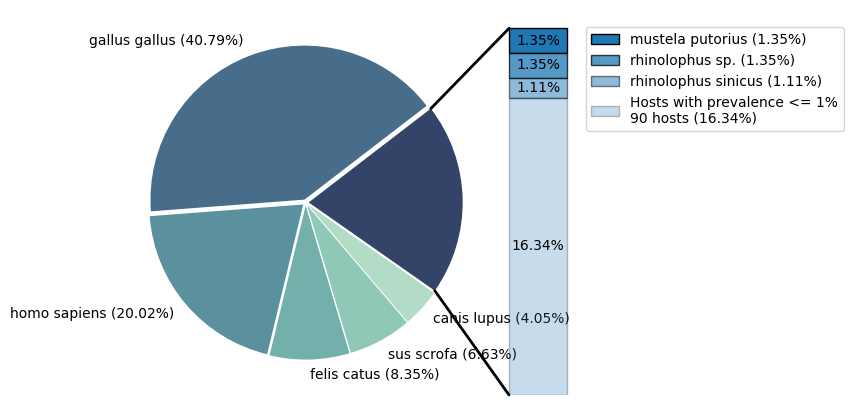

In [17]:
from matplotlib.patches import ConnectionPatch

# make figure and assign axis objects
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
fig.subplots_adjust(wspace=-.5)

# pie chart parameters
explode_val = 0.02
pie_values = [df[~df['virus_host_name'].isin(pie_hosts)].shape[0]]
pie_labels = [""]
explode = [explode_val]
for pie_host in pie_hosts:
    pie_values.append(count_data[pie_host])
    pie_labels.append(prevalence_data[pie_host])
    explode.append(explode_val)
    count_data.pop(pie_host)

# rotate so that first wedge is split by the x-axis
#angle = -180 * overall_ratios[0]
wedges, *_ = ax1.pie(pie_values, startangle=-35,
                     labels=pie_labels, explode=explode, colors=sns.cubehelix_palette(rot=-.4, gamma=.7, n_colors=len(pie_labels)+1, reverse=True))

# bar chart parameters
bar_values = [i for i in reversed(count_data.values())]
bar_labels = [i for i in reversed(count_data.keys())]
bottom = 1
width = 10.1
bar_total = sum(bar_values)

print(bar_total)
# Adding from the top matches the legend.
for j, (val, label) in enumerate(reversed([*zip(bar_values, bar_labels)])):
    height = val / bar_total
    bottom -= height
    bc = ax2.bar(0, height, width, bottom=bottom, color='C0', label=prevalence_data[label], edgecolor="black",
                 alpha=1-(1/len(bar_labels) * j))
    ax2.bar_label(bc, labels=[f"{val/n*100:.2f}%"], label_type='center')

ax2.legend(loc="center",
          bbox_to_anchor=(.88, .82))
ax2.axis('off')
ax2.set_xlim(-4*width, 4*width)

# use ConnectionPatch to draw lines between the two plots
theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center, r = wedges[0].center, wedges[0].r
bar_height = 1

# draw top connecting line
x = r * np.cos(np.pi / 180 * theta2) + center[0]
y = r * np.sin(np.pi / 180 * theta2) + center[1]
con = ConnectionPatch(xyA=(-width / 2, bar_height), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
con.set_linewidth(2)
ax2.add_artist(con)

# draw bottom connecting line
x = r * np.cos(np.pi / 180 * theta1) + center[0]
y = r * np.sin(np.pi / 180 * theta1) + center[1]
con = ConnectionPatch(xyA=(-width / 2, 0), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
ax2.add_artist(con)
con.set_linewidth(2)
#plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", "output/visualization/temp_new/iv_hosts_pie_bar.pdf"), bbox_inches="tight", dpi=600)
plt.show()

## Virus Composition

In [18]:
count_data, label_data, prevalence_data = get_data_for_pie_chart(df, col_name="virus_name", n=n, threshold=.01)
others_viruses = []
for k,v in count_data.items():
    if (v/n*100) <= 1.0:
        others_viruses.append(k)
        
df["virus_name_mod"] = df["virus_name"].apply(lambda x: x if x not in others_viruses else f"Others ({len(others_viruses)} viruses)")

count_data, label_data, prevalence_data = get_data_for_pie_chart(df[~df["virus_name"].isin(others_viruses)], col_name="virus_name_mod", n=n, threshold=0.1)

In [19]:
prevalence_data

{'Infectious bronchitis virus': 'Infectious bronchitis virus (33.29%)',
 'Severe acute respiratory syndrome coronavirus 2': 'Severe acute respiratory syndrome coronavirus 2 (11.43%)',
 'Avian coronavirus': 'Avian coronavirus (7.74%)',
 'Feline coronavirus': 'Feline coronavirus (7.74%)',
 'Human coronavirus OC43': 'Human coronavirus OC43 (6.76%)',
 'Porcine epidemic diarrhea virus': 'Porcine epidemic diarrhea virus (5.77%)',
 'Coronaviridae': 'Coronaviridae (2.58%)',
 'Canine coronavirus': 'Canine coronavirus (2.09%)',
 'Alphacoronavirus 1': 'Alphacoronavirus 1 (1.84%)',
 'Bat coronavirus': 'Bat coronavirus (1.72%)',
 'Orthocoronavirinae': 'Orthocoronavirinae (1.23%)'}

In [20]:
n_others = df[df['virus_name'].isin(others_viruses)].shape[0]
prevalence_data["Viruses with prevalence <= 1%"] = f"Viruses with prevalence <= 1%\n{len(others_viruses)} viruses ({n_others/n*100:.2f}%)"
prevalence_data

{'Infectious bronchitis virus': 'Infectious bronchitis virus (33.29%)',
 'Severe acute respiratory syndrome coronavirus 2': 'Severe acute respiratory syndrome coronavirus 2 (11.43%)',
 'Avian coronavirus': 'Avian coronavirus (7.74%)',
 'Feline coronavirus': 'Feline coronavirus (7.74%)',
 'Human coronavirus OC43': 'Human coronavirus OC43 (6.76%)',
 'Porcine epidemic diarrhea virus': 'Porcine epidemic diarrhea virus (5.77%)',
 'Coronaviridae': 'Coronaviridae (2.58%)',
 'Canine coronavirus': 'Canine coronavirus (2.09%)',
 'Alphacoronavirus 1': 'Alphacoronavirus 1 (1.84%)',
 'Bat coronavirus': 'Bat coronavirus (1.72%)',
 'Orthocoronavirinae': 'Orthocoronavirinae (1.23%)',
 'Viruses with prevalence <= 1%': 'Viruses with prevalence <= 1%\n92 viruses (17.81%)'}

In [21]:
count_data

{'Infectious bronchitis virus': 271,
 'Severe acute respiratory syndrome coronavirus 2': 93,
 'Avian coronavirus': 63,
 'Feline coronavirus': 63,
 'Human coronavirus OC43': 55,
 'Porcine epidemic diarrhea virus': 47,
 'Coronaviridae': 21,
 'Canine coronavirus': 17,
 'Alphacoronavirus 1': 15,
 'Bat coronavirus': 14,
 'Orthocoronavirinae': 10}

In [22]:
count_data["Viruses with prevalence <= 1%"] = n_others
count_data

{'Infectious bronchitis virus': 271,
 'Severe acute respiratory syndrome coronavirus 2': 93,
 'Avian coronavirus': 63,
 'Feline coronavirus': 63,
 'Human coronavirus OC43': 55,
 'Porcine epidemic diarrhea virus': 47,
 'Coronaviridae': 21,
 'Canine coronavirus': 17,
 'Alphacoronavirus 1': 15,
 'Bat coronavirus': 14,
 'Orthocoronavirinae': 10,
 'Viruses with prevalence <= 1%': 145}

In [23]:
pie_viruses = ["Infectious bronchitis virus", "Severe acute respiratory syndrome coronavirus 2", "Avian coronavirus", "Feline coronavirus", "Human coronavirus OC43", "Porcine epidemic diarrhea virus"]

In [24]:
df["virus_name"].nunique()

103

222


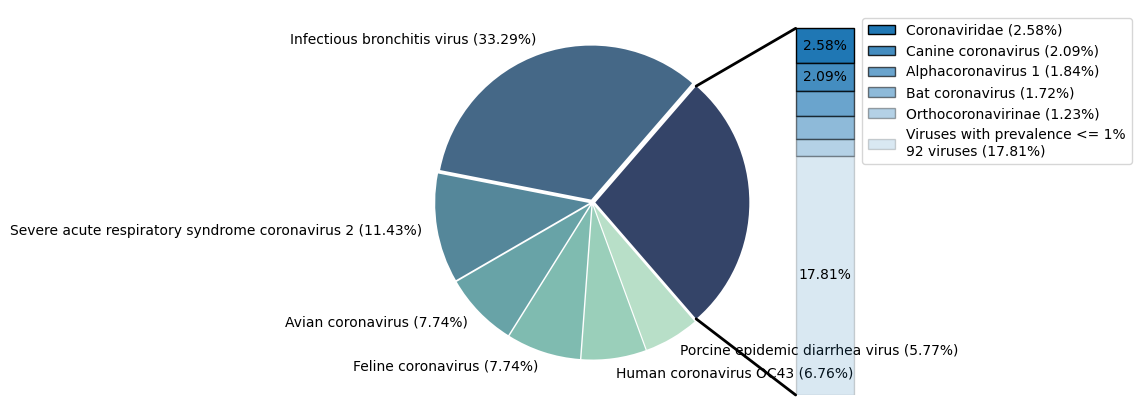

In [25]:
from matplotlib.patches import ConnectionPatch

# make figure and assign axis objects
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
fig.subplots_adjust(wspace=-.5)

# pie chart parameters
explode_val = 0.02
pie_values = [df[~df['virus_name'].isin(pie_viruses)].shape[0]]
pie_labels = [""]
explode = [explode_val]
for pie_virus in pie_viruses:
    pie_values.append(count_data[pie_virus])
    pie_labels.append(prevalence_data[pie_virus])
    explode.append(explode_val)
    count_data.pop(pie_virus)

    
# rotate so that first wedge is split by the x-axis
#angle = -180 * overall_ratios[0]
wedges, *_ = ax1.pie(pie_values, startangle=-180 * pie_values[0]/n, #wedgeprops={"linewidth": 1, "edgecolor": "white"},
                     labels=pie_labels, explode=explode, colors=sns.cubehelix_palette(rot=-.4, gamma=.7, n_colors=len(pie_labels)+1, reverse=True))

# bar chart parameters
bar_values = [i for i in reversed(count_data.values())]
bar_labels = [i for i in reversed(count_data.keys())]
bottom = 1
width = 10.1
bar_total = sum(bar_values)

print(bar_total)
# Adding from the top matches the legend.
for j, (val, label) in enumerate(reversed([*zip(bar_values, bar_labels)])):
    height = val / bar_total
    bottom -= height
    bc = ax2.bar(0, height, width, bottom=bottom, color='C0', label=prevalence_data[label], edgecolor="black", 
                 alpha=1-(1/len(bar_labels) * j))
    label_pct = val/n*100
    if label_pct > 2:
        ax2.bar_label(bc, labels=[f"{val/n*100:.2f}%"], label_type='center')

ax2.legend(loc="center",
          bbox_to_anchor=(.87, .79))
ax2.axis('off')
ax2.set_xlim(-4*width, 4*width)

# use ConnectionPatch to draw lines between the two plots
theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center, r = wedges[0].center, wedges[0].r
bar_height = 1

# draw top connecting line
x = r * np.cos(np.pi / 180 * theta2) + center[0]
y = r * np.sin(np.pi / 180 * theta2) + center[1]
con = ConnectionPatch(xyA=(-width / 2, bar_height), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
con.set_linewidth(2)
ax2.add_artist(con)

# draw bottom connecting line
x = r * np.cos(np.pi / 180 * theta1) + center[0]
y = r * np.sin(np.pi / 180 * theta1) + center[1]
con = ConnectionPatch(xyA=(-width / 2, 0), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
ax2.add_artist(con)
con.set_linewidth(2)
#plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", "output/visualization/temp_new/noniv_viruses_pie_bar.pdf"), bbox_inches="tight", dpi=600)
plt.show()

## Virus Host Composition

In [26]:
count_data, label_data, prevalence_data = get_data_for_pie_chart(df, col_name="virus_host_name", n=n, threshold=1)
others_hosts = []
for k,v in count_data.items():
    if (v/n*100) <= 1.0:
        others_hosts.append(k)
        
df["virus_host_name_mod"] = df["virus_host_name"].apply(lambda x: x if x not in others_hosts else f"Rare ({len(others_hosts)} hosts)")

count_data, label_data, prevalence_data = get_data_for_pie_chart(df[~df["virus_host_name"].isin(others_hosts)], col_name="virus_host_name_mod", n=n, threshold=0.01)
prevalence_data

{'gallus gallus': 'gallus gallus (40.79%)',
 'homo sapiens': 'homo sapiens (20.02%)',
 'felis catus': 'felis catus (8.35%)',
 'sus scrofa': 'sus scrofa (6.63%)',
 'canis lupus': 'canis lupus (4.05%)',
 'mustela putorius': 'mustela putorius (1.35%)',
 'rhinolophus sp.': 'rhinolophus sp. (1.35%)',
 'rhinolophus sinicus': 'rhinolophus sinicus (1.11%)'}

In [27]:
n_others = df[df['virus_host_name'].isin(others_hosts)].shape[0]
prevalence_data["Hosts with prevalence <= 1%"] = f"Hosts with prevalence <= 1% ({len(others_hosts)} hosts)\n({n_others/n*100:.2f}%)"
prevalence_data

{'gallus gallus': 'gallus gallus (40.79%)',
 'homo sapiens': 'homo sapiens (20.02%)',
 'felis catus': 'felis catus (8.35%)',
 'sus scrofa': 'sus scrofa (6.63%)',
 'canis lupus': 'canis lupus (4.05%)',
 'mustela putorius': 'mustela putorius (1.35%)',
 'rhinolophus sp.': 'rhinolophus sp. (1.35%)',
 'rhinolophus sinicus': 'rhinolophus sinicus (1.11%)',
 'Hosts with prevalence <= 1%': 'Hosts with prevalence <= 1% (90 hosts)\n(16.34%)'}

In [28]:
count_data

{'gallus gallus': 332,
 'homo sapiens': 163,
 'felis catus': 68,
 'sus scrofa': 54,
 'canis lupus': 33,
 'mustela putorius': 11,
 'rhinolophus sp.': 11,
 'rhinolophus sinicus': 9}

In [29]:
count_data["Hosts with prevalence <= 1%"] = n_others
count_data

{'gallus gallus': 332,
 'homo sapiens': 163,
 'felis catus': 68,
 'sus scrofa': 54,
 'canis lupus': 33,
 'mustela putorius': 11,
 'rhinolophus sp.': 11,
 'rhinolophus sinicus': 9,
 'Hosts with prevalence <= 1%': 133}

40.78623950481415
20.02456933259964
8.353808522224426
6.633906811475754
4.054053872823715
1.3513513840734959
1.3513513840734959
1.1056510731577873
16.33906662464142


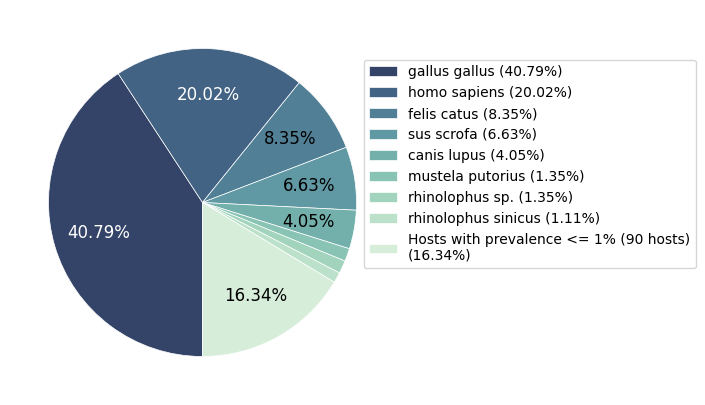

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

def get_label(pct, threshold):
    print(pct)
    if pct <= threshold:
        return ""
    else:
        return f"{pct:.2f}%"

threshold=1.0
wedges, texts, autotexts = ax.pie(count_data.values(), autopct=lambda pct: get_label(pct, threshold=3), 
                                  pctdistance=.7, labeldistance=.7, counterclock=False, startangle=-90,
                                  colors=sns.cubehelix_palette(rot=-.4, gamma=.7, n_colors=len(count_data), reverse=True), 
                                  wedgeprops={"linewidth": .5, "edgecolor": "white"})

ax.legend(wedges, prevalence_data.values(),
          title="",
          loc="center",
          bbox_to_anchor=(1.35, .6), ncol=1)
plt.setp(autotexts, size=12, color="black")
plt.setp(autotexts[0], size=12, color="white")
plt.setp(autotexts[1], size=12, color="white")
plt.setp(autotexts[-1], size=12, color="black")
#ax.set_title("IV Dataset", fontsize=14, y=0, pad=0)
plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", "..", "output/visualization/haven/cov_s_uniref90_virus_host_distribution.pdf"), bbox_inches="tight", dpi=1024)
plt.show()

## Virus Composition

In [31]:
count_data, label_data, prevalence_data = get_data_for_pie_chart(df, col_name="virus_name", n=n, threshold=1)
others_viruses = []
for k,v in count_data.items():
    if (v/n*100) <= 1.0:
        others_viruses.append(k)
        
df["virus_name_mod"] = df["virus_name"].apply(lambda x: x if x not in others_viruses else f"Rare ({len(others_viruses)} viruses)")

count_data, label_data, prevalence_data = get_data_for_pie_chart(df[~df["virus_name"].isin(others_viruses)], col_name="virus_name_mod", n=n, threshold=0.01)
prevalence_data

{'Infectious bronchitis virus': 'Infectious bronchitis virus (33.29%)',
 'Severe acute respiratory syndrome coronavirus 2': 'Severe acute respiratory syndrome coronavirus 2 (11.43%)',
 'Avian coronavirus': 'Avian coronavirus (7.74%)',
 'Feline coronavirus': 'Feline coronavirus (7.74%)',
 'Human coronavirus OC43': 'Human coronavirus OC43 (6.76%)',
 'Porcine epidemic diarrhea virus': 'Porcine epidemic diarrhea virus (5.77%)',
 'Coronaviridae': 'Coronaviridae (2.58%)',
 'Canine coronavirus': 'Canine coronavirus (2.09%)',
 'Alphacoronavirus 1': 'Alphacoronavirus 1 (1.84%)',
 'Bat coronavirus': 'Bat coronavirus (1.72%)',
 'Orthocoronavirinae': 'Orthocoronavirinae (1.23%)'}

In [32]:
n_others = df[df['virus_name'].isin(others_viruses)].shape[0]
prevalence_data["Viruses with prevalence <= 1%"] = f"Viruses with prevalence <= 1% ({len(others_viruses)} viruses)\n({n_others/n*100:.2f}%)"
prevalence_data

{'Infectious bronchitis virus': 'Infectious bronchitis virus (33.29%)',
 'Severe acute respiratory syndrome coronavirus 2': 'Severe acute respiratory syndrome coronavirus 2 (11.43%)',
 'Avian coronavirus': 'Avian coronavirus (7.74%)',
 'Feline coronavirus': 'Feline coronavirus (7.74%)',
 'Human coronavirus OC43': 'Human coronavirus OC43 (6.76%)',
 'Porcine epidemic diarrhea virus': 'Porcine epidemic diarrhea virus (5.77%)',
 'Coronaviridae': 'Coronaviridae (2.58%)',
 'Canine coronavirus': 'Canine coronavirus (2.09%)',
 'Alphacoronavirus 1': 'Alphacoronavirus 1 (1.84%)',
 'Bat coronavirus': 'Bat coronavirus (1.72%)',
 'Orthocoronavirinae': 'Orthocoronavirinae (1.23%)',
 'Viruses with prevalence <= 1%': 'Viruses with prevalence <= 1% (92 viruses)\n(17.81%)'}

In [33]:
count_data["Viruses with prevalence <= 1%"] = n_others
count_data

{'Infectious bronchitis virus': 271,
 'Severe acute respiratory syndrome coronavirus 2': 93,
 'Avian coronavirus': 63,
 'Feline coronavirus': 63,
 'Human coronavirus OC43': 55,
 'Porcine epidemic diarrhea virus': 47,
 'Coronaviridae': 21,
 'Canine coronavirus': 17,
 'Alphacoronavirus 1': 15,
 'Bat coronavirus': 14,
 'Orthocoronavirinae': 10,
 'Viruses with prevalence <= 1%': 145}

33.29238295555115
11.425061523914337
7.739558070898056
7.739558070898056
6.756756454706192
5.7739559561014175
2.5798525661230087
2.0884521305561066
1.8427519127726555
1.7199017107486725
1.2285011820495129
17.813268303871155


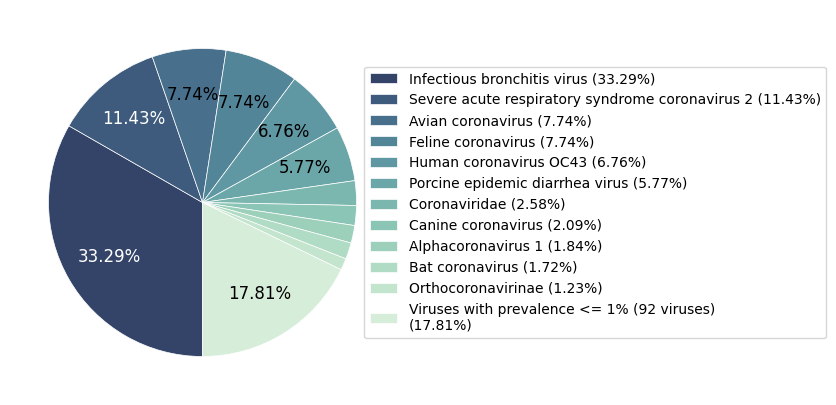

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))

def get_label(pct, threshold):
    print(pct)
    if pct <= threshold:
        return ""
    else:
        return f"{pct:.2f}%"

threshold=1.0
wedges, texts, autotexts = ax.pie(count_data.values(), autopct=lambda pct: get_label(pct, threshold=3), 
                                  pctdistance=.7, labeldistance=.7, counterclock=False, startangle=-90,
                                  colors=sns.cubehelix_palette(rot=-.4, gamma=.7, n_colors=len(count_data), reverse=True), 
                                  wedgeprops={"linewidth": .5, "edgecolor": "white"})

ax.legend(wedges, prevalence_data.values(),
          title="",
          loc="center",
          bbox_to_anchor=(1.52, .5), ncol=1)
plt.setp(autotexts, size=12, color="black")
plt.setp(autotexts[0], size=12, color="white")
plt.setp(autotexts[1], size=12, color="white")
plt.setp(autotexts[-1], size=12, color="black")
#ax.set_title("IV Dataset", fontsize=14, y=0, pad=0)
plt.savefig(os.path.join(os.getcwd(), "..", "..", "..", "..", "..", "output/visualization/haven/cov_s_uniref90_virus_distribution.pdf"), bbox_inches="tight", dpi=600)
plt.show()

## Sequence Length Distribution

In [60]:
def seq_length_analysis(input_file_path, output_file_path):
    df = pd.read_csv(input_file_path)
    df["seq_len"] = df["seq"].apply(lambda x: len(x))
    print(f"min = {df['seq_len'].min()}")
    print(f"max = {df['seq_len'].max()}")
    plt.clf()
    sns.set_theme()
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(df["seq_len"].values, bins=300, ax=ax, fill=True, alpha=1, kde=False, color=sns.color_palette("dark")[0])
    sns.rugplot(data=df, x="seq_len", height=-.03, clip_on=False, color="black", alpha=.5)
    ax.set_xlabel("Sequence Length", fontsize=12)
    ax.set_ylabel("Number of sequences", fontsize=12)
    ax.set_xticks(np.arange(0, df["seq_len"].max() + 1, 100))
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
    ax.set_xlim((0, df["seq_len"].max() + 10))
    plt.savefig(output_file_path, bbox_inches="tight", dpi=600)
    plt.show()

### Finetuning Dataset

min = 18
max = 1582


<Figure size 640x480 with 0 Axes>

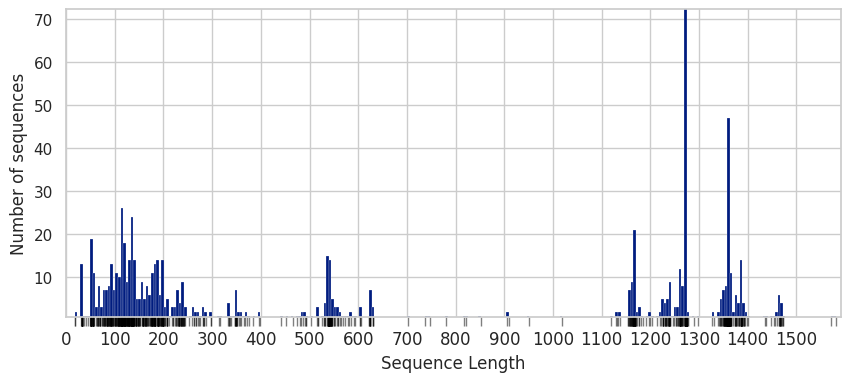

In [61]:
seq_length_analysis(os.path.join(os.getcwd(), "..", "..", "..", "..", "input/data/coronaviridae/20240313/uniref/coronaviridae_s_uniref90_embl_hosts_pruned_metadata_corrected_species_virus_host_vertebrates_w_seq.csv"),
                    os.path.join(os.getcwd(), "..", "..", "..", "..", "output/visualization/haven/cov_s_uniref90_dataset_seqlength_dist.pdf"))